In [1]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: D:\anaconda3\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [3]:
df = pd.read_csv("housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## EDA

In [4]:
df.shape

(545, 13)

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Check Duplicate Data

In [9]:
df.duplicated().sum()

np.int64(0)

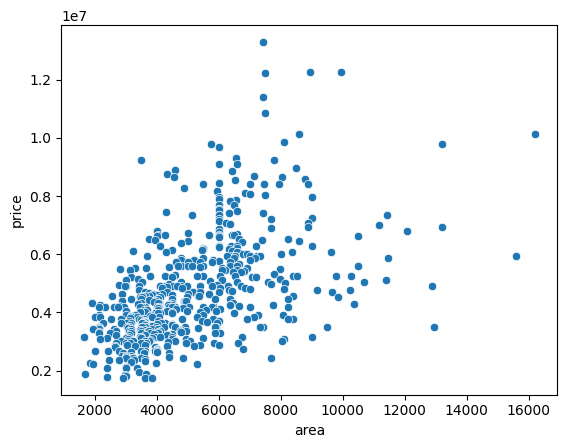

In [11]:
sns.scatterplot(x='area', y='price', data=df)
plt.show()

### Correlation Analysis

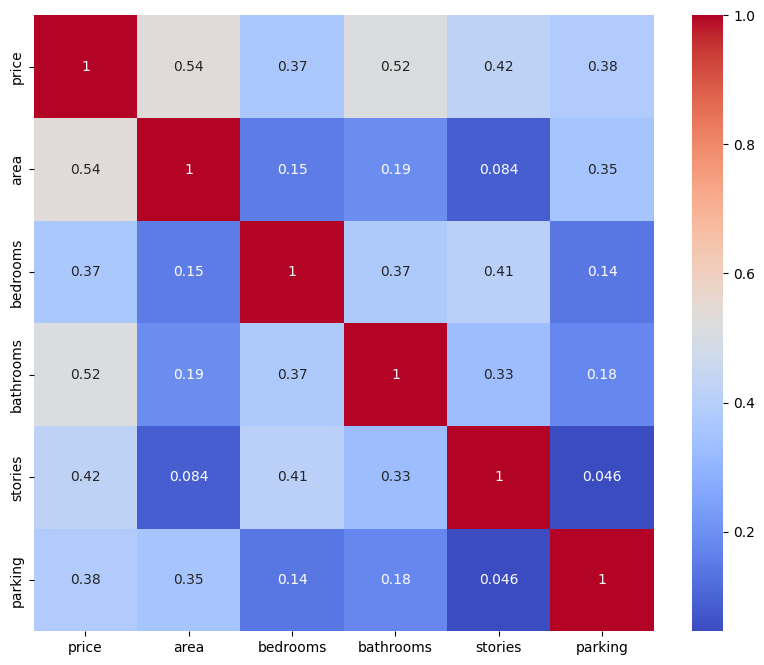

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Detect Outliers

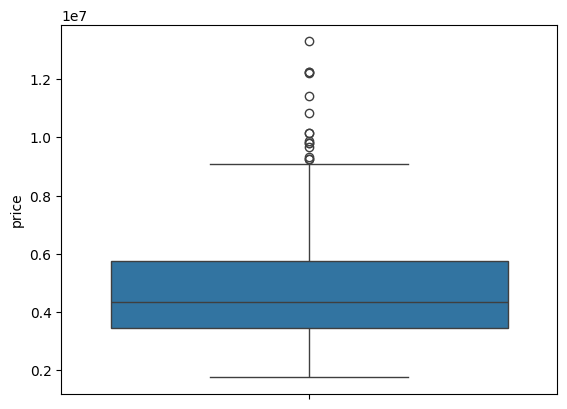

In [13]:
sns.boxplot(df['price'])
plt.show()

### Separate Features & Target

In [14]:
X = df.drop("price", axis=1)

y = df["price"]

In [15]:
num_cols = X.select_dtypes(include=np.number).columns

cat_cols = X.select_dtypes(exclude=np.number).columns

## Preprocessing Pipeline

In [16]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

## Create Model Dictionary

In [18]:
models = {

    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(),

    "Lasso": Lasso(),

    "ElasticNet": ElasticNet(),

    "DecisionTree": DecisionTreeRegressor(),

    "RandomForest": RandomForestRegressor(),

    "GradientBoosting": GradientBoostingRegressor(),

    "AdaBoost": AdaBoostRegressor(),

    "ExtraTrees": ExtraTreesRegressor(),

    "KNeighbors": KNeighborsRegressor(),

    "SVR": SVR(),

    "XGBoost": XGBRegressor(),

    "LightGBM": LGBMRegressor(),

    "CatBoost": CatBoostRegressor(verbose=0)
}

## Hyperparameter Tuning Parameters

In [19]:
params = {

    "RandomForest": {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None],
        'model__min_samples_split': [2, 5]
    },

    "GradientBoosting": {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 5]
    },

    "XGBoost": {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 5, 7]
    },

    "LightGBM": {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1]
    },

    "CatBoost": {
        'model__iterations': [100, 200],
        'model__learning_rate': [0.01, 0.1],
        'model__depth': [4, 6, 8]
    }
}

## Train All Models with Hyperparameter Tuning

In [20]:
results = {}

best_model = None
best_score = -999

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    print(f"Training {name}...")

    if name in params:

        grid = RandomizedSearchCV(
            pipeline,
            params[name],
            cv=5,
            scoring='r2',
            n_iter=5,
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        final_model = grid.best_estimator_

    else:

        pipeline.fit(X_train, y_train)

        final_model = pipeline

    y_pred = final_model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {
        "R2 Score": r2,
        "MAE": mae,
        "RMSE": rmse
    }

    if r2 > best_score:
        best_score = r2
        best_model = final_model

    print(f"{name} Completed")

Training LinearRegression...
LinearRegression Completed
Training Ridge...
Ridge Completed
Training Lasso...
Lasso Completed
Training ElasticNet...
ElasticNet Completed
Training DecisionTree...
DecisionTree Completed
Training RandomForest...
RandomForest Completed
Training GradientBoosting...
GradientBoosting Completed
Training AdaBoost...
AdaBoost Completed
Training ExtraTrees...
ExtraTrees Completed
Training KNeighbors...
KNeighbors Completed
Training SVR...
SVR Completed
Training XGBoost...
XGBoost Completed
Training LightGBM...


D:\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 155
[LightGBM] [Info] Number of data points in the train set: 436, number of used features: 20
[LightGBM] [Info] Start training from score 4706527.385321
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

D:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CatBoost Completed


In [21]:
df["price_per_sqft"] = df["price"] / df["area"]

df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

In [22]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(scores.mean())

-11.208151134129535


In [ ]:
results_df = pd.DataFrame(results).T

print(results_df.sort_values(by="R2 Score", ascending=False))